In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
path = "C:/Users/mikan/Documents/ds4300/practical02/src/stats"
#path = "/Users/annabirge/Documents/courses/ds4300_s25/practical02/src/stats"

dfs = []

for file in os.listdir(path):
    if file.endswith("_search.csv"):  
        file_path = os.path.join(path, file) 
        df = pd.read_csv(file_path)  
        dfs.append(df) 

if dfs: 
    final_df = pd.concat(dfs, ignore_index=True)  
else:
    print("No CSV files found in the directory.")

#final_df
path = "C:/Users/mikan/Documents/ds4300/practical02/src/stats"
#path = "/Users/annabirge/Documents/courses/ds4300_s25/practical02/src/stats"

dfs = []

for file in os.listdir(path):
    if file.endswith("_processing.csv"):  
        file_path = os.path.join(path, file) 
        df = pd.read_csv(file_path)  
        dfs.append(df) 

if dfs: 
    proc_df = pd.concat(dfs, ignore_index=True)    
else:
    print("No CSV files found in the directory.")
proc_df

,vector_db,embedding_model,peak_memory_mb,total_processing_time,docs_processed,chunks_processed,chunk_size,chunk_overlap
0,chroma,all-mpnet-base-v2,13.660134,45.920271,13,207,100,20
1,chroma,nomic-embed-text,1.036328,58.876756,13,207,100,20
2,chroma,hkunlp/instructor-xl,13.877860,483.915498,13,207,100,20
3,chroma,hkunlp/instructor-xl,13.904003,907.357421,13,115,200,20
4,chroma,all-mpnet-base-v2,13.809681,57.579723,13,115,200,20
5,chroma,nomic-embed-text,1.212001,48.460130,13,115,200,20
6,mongo,all-mpnet-base-v2,39.126067,210.785383,13,207,100,20
7,mongo,all-mpnet-base-v2,37.076874,141.026857,13,115,200,20
8,mongo,nomic-embed-text,0.762557,13.630891,13,207,100,20
9,mongo,all-mpnet-base-v2,54.116156,44.720019,13,207,100,20


C:\Users\mikan\AppData\Local\Temp\ipykernel_33176\1076548650.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=dbs)


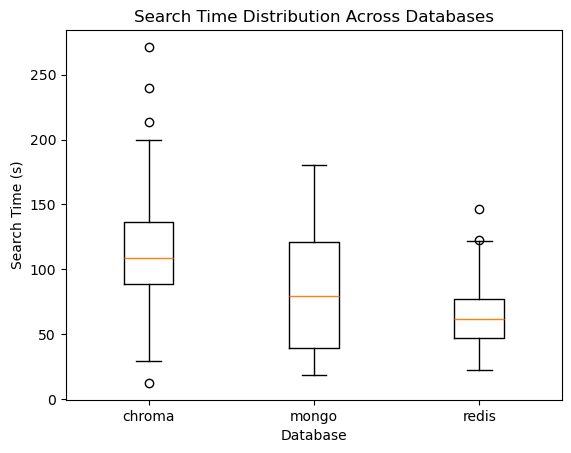

In [15]:
## 1. Boxplot: Query Time Distribution by Database
dbs = final_df[" database"].unique()
data = [final_df[final_df[" database"] == db][" total_time"].dropna() for db in dbs]
plt.boxplot(data, labels=dbs)
plt.title("Search Time Distribution Across Databases")
plt.xlabel("Database")
plt.ylabel("Search Time (s)")
plt.savefig("dist.png")
plt.show()

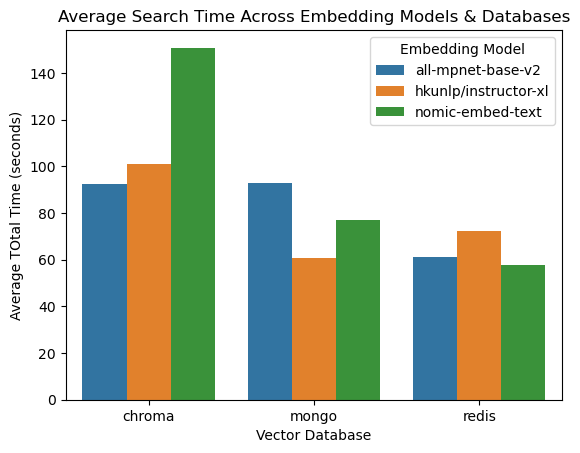

In [16]:
avg_query_time = final_df.groupby([" database", " embedding_model"])[" total_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x=" database", y=" total_time", hue=" embedding_model")
plt.title("Average Search Time Across Embedding Models & Databases")
plt.xlabel("Vector Database")
plt.ylabel("Average TOtal Time (seconds)")
plt.legend(title="Embedding Model")
plt.savefig("avg_search_dbs.png")
plt.show()

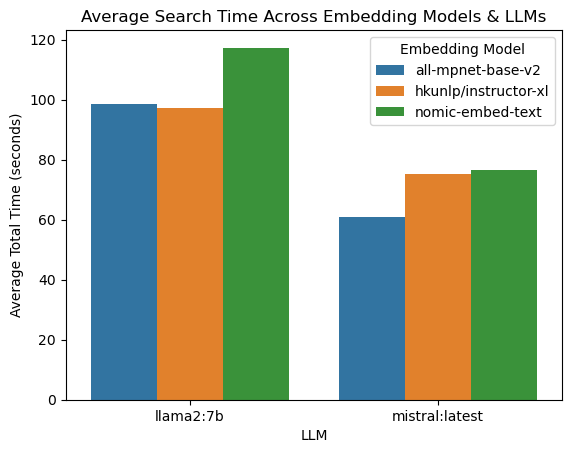

In [17]:
avg_query_time = final_df.groupby([" llm", " embedding_model"])[" total_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x=" llm", y=" total_time", hue=" embedding_model")
plt.title("Average Search Time Across Embedding Models & LLMs")
plt.xlabel("LLM")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="Embedding Model")
plt.savefig("avg_search_models.png")
plt.show()

C:\Users\mikan\AppData\Local\Temp\ipykernel_33176\4210513806.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=dbs)


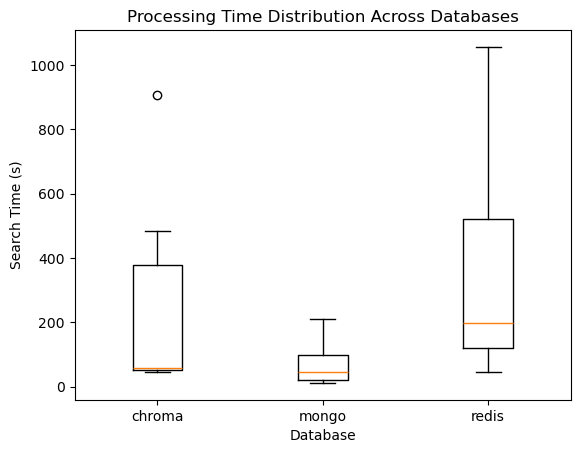

In [18]:
dbs = proc_df["vector_db"].unique()
data = [proc_df[proc_df["vector_db"] == db]["total_processing_time"].dropna() for db in dbs]
plt.boxplot(data, labels=dbs)
plt.title("Processing Time Distribution Across Databases")
plt.xlabel("Database")
plt.ylabel("Search Time (s)")
plt.savefig("search_time.png")
plt.show()

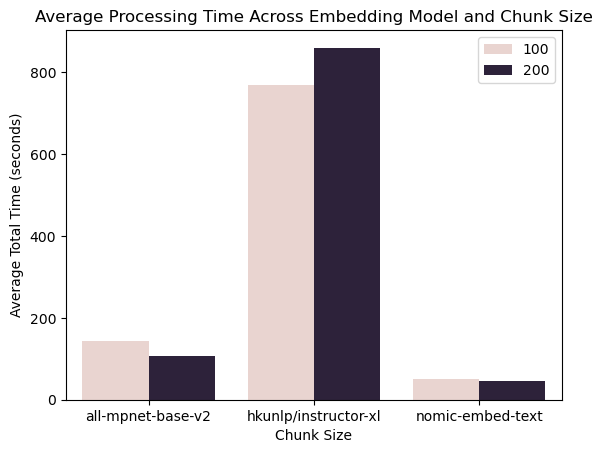

In [22]:
avg_query_time = proc_df.groupby(["embedding_model", "chunk_size"])["total_processing_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x="embedding_model", y="total_processing_time", hue = "chunk_size")
plt.title("Average Processing Time Across Embedding Model and Chunk Size")
plt.xlabel("Chunk Size")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.savefig("chunk_size.png")
plt.show()

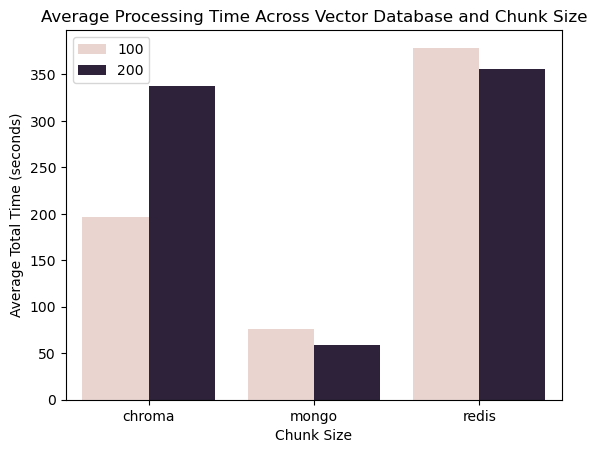

In [23]:
avg_query_time = proc_df.groupby(["vector_db", "chunk_size"])["total_processing_time"].mean().reset_index()
sns.barplot(data=avg_query_time, x="vector_db", y="total_processing_time", hue = "chunk_size")
plt.title("Average Processing Time Across Vector Database and Chunk Size")
plt.xlabel("Chunk Size")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.savefig("searchtime_db.png")
plt.show()

/var/folders/5s/06s5mmfx0kz9vq59yd5f1l7c0000gn/T/ipykernel_14756/1587515403.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=avg_query_time, x="vector_db", y="peak_memory_mb", hue = "embedding_model",ci=None)


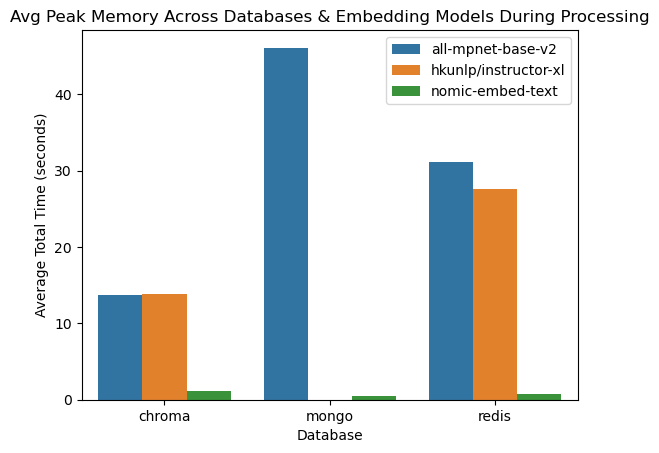

In [16]:
avg_query_time = proc_df.groupby(["vector_db", "embedding_model"])["peak_memory_mb"].mean().reset_index()
sns.barplot(data=avg_query_time, x="vector_db", y="peak_memory_mb", hue = "embedding_model",ci=None)
plt.title("Avg Peak Memory Across Databases & Embedding Models During Processing")
plt.xlabel("Database")
plt.ylabel("Average Total Time (seconds)")
plt.legend(title="")
plt.savefig("processing_memory1.png")
plt.show()

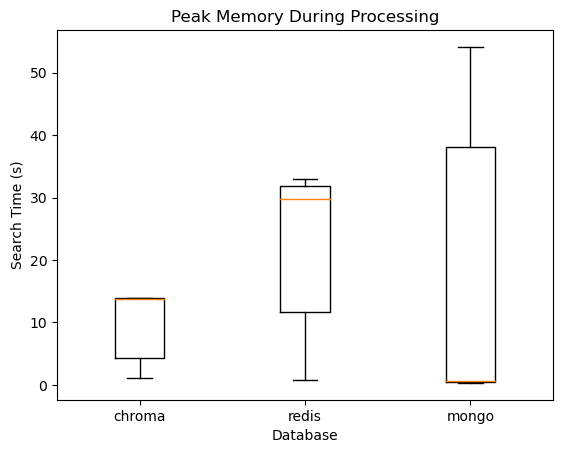

In [14]:
## 1. Boxplot: Query Time Distribution by Database
dbs = proc_df["vector_db"].unique()
data = [proc_df[proc_df["vector_db"] == db]["peak_memory_mb"].dropna() for db in dbs]
plt.boxplot(data, labels=dbs)
plt.title("Peak Memory During Processing")
plt.xlabel("Database")
plt.ylabel("Search Time (s)")
plt.savefig("processing_memory2.png")
plt.show()